**Problem Statement:**

Given multimodal physiological signals (ECG, EDA, Skin Temperature) recorded from subjects
wearing a chest-mounted RespiBAN sensor, design and implement a machine learning pipeline
that can accurately classify whether a subject is in a Baseline (relaxed) or Stress state,
generalizing across unseen individuals (person-independent model).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'neurokit2', 'scipy', 'scikit-learn',
                'matplotlib', 'seaborn', '-q'])
print("✓ Libraries ready")

✓ Libraries ready


In [ ]:
import pickle, os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)
from sklearn.model_selection import LeaveOneGroupOut
import neurokit2 as nk
import warnings
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────
ZIP_PATH     = '/content/drive/MyDrive/Colab Notebooks/archive.zip'
EXTRACT_PATH = '/content/WESAD/WESAD'   # your actual extracted path
SUBJECTS     = [f'S{i}' for i in [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]]
WINDOW_SIZE  = 700 * 60   # 60s at 700 Hz
STEP_SIZE    = 700 * 30   # 50% overlap

print("✓ All imports done")
print("✓ EXTRACT_PATH:", EXTRACT_PATH)
print("✓ Subjects:", SUBJECTS)

✓ All imports done
✓ EXTRACT_PATH: /content/WESAD/WESAD
✓ Subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


In [ ]:
RAW_EXTRACT = '/content/WESAD'

if not os.path.exists(RAW_EXTRACT):
    os.makedirs(RAW_EXTRACT, exist_ok=True)
    print("Extracting... (2–5 mins)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RAW_EXTRACT)
    print("Done!")
else:
    print("Already extracted, skipping.")

print("Contents:", os.listdir(EXTRACT_PATH))

Extracting... (2–5 mins)
Done!
Contents: ['S2', 'S14', 'S16', 'S5', 'S17', 'S7', 'S4', 'wesad_readme.pdf', 'S13', 'S10', 'S6', 'S3', 'S15', 'S8', 'S11', 'S9']


In [ ]:
def load_subject(subject_id, base_path=EXTRACT_PATH):
    pkl_path = os.path.join(base_path, subject_id, f'{subject_id}.pkl')
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

def extract_signals(data, device='chest'):
    signals = data['signal'][device]
    labels  = data['label']
    return signals, labels

# Quick test
d = load_subject('S2')
sig, lab = extract_signals(d, 'chest')
print("Chest signals:", list(sig.keys()))
print("Label distribution:", {int(k): int(v) for k,v in zip(*np.unique(lab, return_counts=True))})

Chest signals: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Label distribution: {0: 2142701, 1: 800800, 2: 430500, 3: 253400, 4: 537599, 6: 45500, 7: 44800}


In [ ]:
def extract_features_window(ecg, eda, temp, fs=700):
    feats = {}
    try:
        ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs)
        peaks, _  = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
        hrv       = nk.hrv_time(peaks, sampling_rate=fs, show=False)
        feats['hrv_meanNN'] = hrv['HRV_MeanNN'].values[0]
        feats['hrv_sdnn']   = hrv['HRV_SDNN'].values[0]
        feats['hrv_rmssd']  = hrv['HRV_RMSSD'].values[0]
        feats['hrv_pnn50']  = hrv['HRV_pNN50'].values[0]
    except:
        feats.update({'hrv_meanNN': np.nan, 'hrv_sdnn': np.nan,
                      'hrv_rmssd': np.nan,  'hrv_pnn50': np.nan})
    feats['eda_mean']   = np.mean(eda)
    feats['eda_std']    = np.std(eda)
    feats['eda_slope']  = np.polyfit(np.arange(len(eda)), eda, 1)[0]
    feats['eda_max']    = np.max(eda)
    feats['temp_mean']  = np.mean(temp)
    feats['temp_std']   = np.std(temp)
    feats['temp_slope'] = np.polyfit(np.arange(len(temp)), temp, 1)[0]
    return feats

def process_subject(subject_id):
    data = load_subject(subject_id)
    signals, labels = extract_signals(data, 'chest')
    ecg  = signals['ECG'].flatten()
    eda  = signals['EDA'].flatten()
    temp = signals['Temp'].flatten()
    rows = []
    for start in range(0, len(ecg) - WINDOW_SIZE, STEP_SIZE):
        end = start + WINDOW_SIZE
        window_labels = labels[start:end]
        unique, counts = np.unique(window_labels, return_counts=True)
        label_map = dict(zip(unique, counts))
        if label_map.get(1, 0) / len(window_labels) > 0.8:
            win_label = 0
        elif label_map.get(2, 0) / len(window_labels) > 0.8:
            win_label = 1
        else:
            continue
        feats = extract_features_window(ecg[start:end], eda[start:end], temp[start:end])
        feats['label']   = win_label
        feats['subject'] = subject_id
        rows.append(feats)
    return pd.DataFrame(rows)

print("✓ Functions defined")

✓ Functions defined


In [ ]:
all_dfs = []
for s in SUBJECTS:
    try:
        print(f"Processing {s}...", end=' ')
        df = process_subject(s)
        all_dfs.append(df)
        print(f"{len(df)} windows")
    except Exception as e:
        print(f"SKIP ({e})")

dataset = pd.concat(all_dfs, ignore_index=True)
dataset.dropna(inplace=True)
print(f"\nTotal windows: {len(dataset)}")
print(dataset['label'].value_counts())

Processing S2... 56 windows
Processing S3... 57 windows
Processing S4... 57 windows
Processing S5... 59 windows
Processing S6... 59 windows
Processing S7... 59 windows
Processing S8... 59 windows
Processing S9... 58 windows
Processing S10... 60 windows
Processing S11... 59 windows
Processing S13... 59 windows
Processing S14... 59 windows
Processing S15... 60 windows
Processing S16... 61 windows
Processing S17... 61 windows

Total windows: 883
label
0    570
1    313
Name: count, dtype: int64


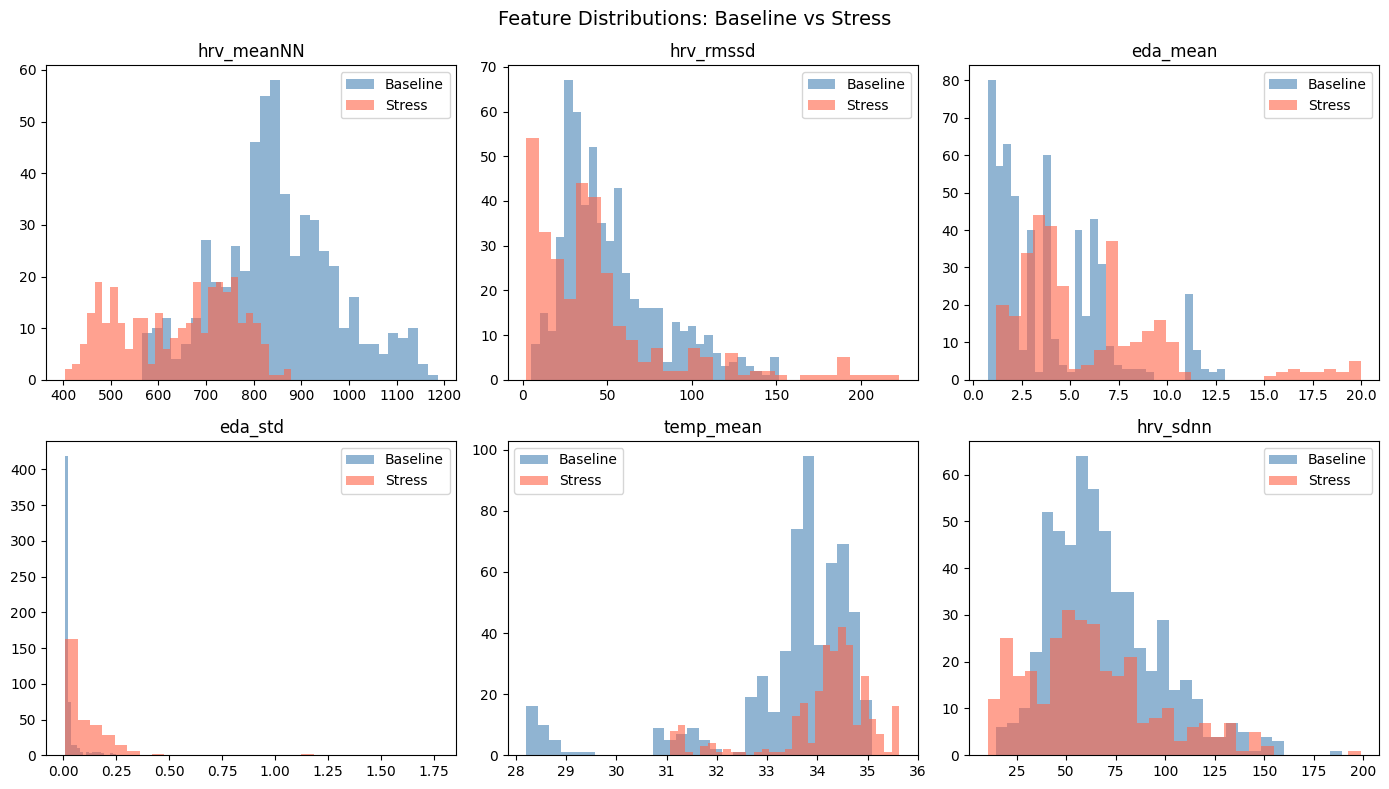

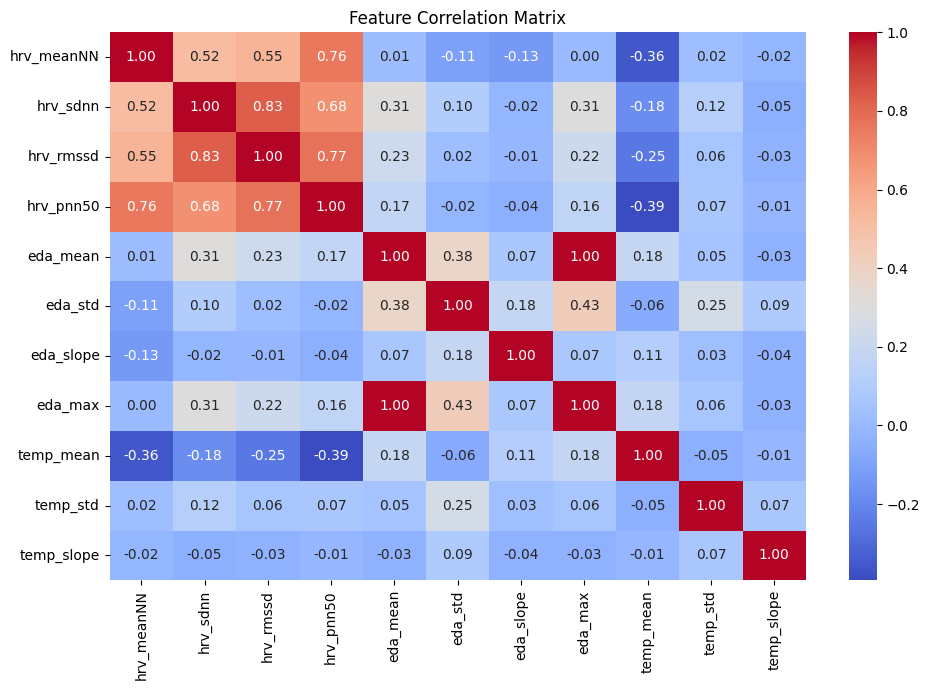

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions: Baseline vs Stress', fontsize=14)

features_to_plot = ['hrv_meanNN', 'hrv_rmssd', 'eda_mean', 'eda_std', 'temp_mean', 'hrv_sdnn']
labels_str = {0: 'Baseline', 1: 'Stress'}

for ax, feat in zip(axes.flatten(), features_to_plot):
    for lbl, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = dataset[dataset['label'] == lbl][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=labels_str[lbl], color=color)
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

# Correlation heatmap
feat_cols = [c for c in dataset.columns if c not in ['label', 'subject']]
plt.figure(figsize=(10, 7))
sns.heatmap(dataset[feat_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
feat_cols = [c for c in dataset.columns if c not in ['label', 'subject']]
X = dataset[feat_cols].values
y = dataset['label'].values
groups = dataset['subject'].values

scaler = StandardScaler()
logo   = LeaveOneGroupOut()

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':     SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, clf in models.items():
    preds, truths = [], []
    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        clf.fit(X_tr, y_tr)
        preds.extend(clf.predict(X_te))
        truths.extend(y_te)

    acc = accuracy_score(truths, preds)
    results[name] = {'accuracy': acc, 'preds': preds, 'truths': truths}
    print(f"\n{'='*40}")
    print(f"Model: {name}  |  LOSO Accuracy: {acc:.3f}")
    print(classification_report(truths, preds, target_names=['Baseline', 'Stress']))


Model: Random Forest  |  LOSO Accuracy: 0.923
              precision    recall  f1-score   support

    Baseline       0.92      0.96      0.94       570
      Stress       0.92      0.86      0.89       313

    accuracy                           0.92       883
   macro avg       0.92      0.91      0.91       883
weighted avg       0.92      0.92      0.92       883


Model: SVM (RBF)  |  LOSO Accuracy: 0.881
              precision    recall  f1-score   support

    Baseline       0.91      0.91      0.91       570
      Stress       0.83      0.83      0.83       313

    accuracy                           0.88       883
   macro avg       0.87      0.87      0.87       883
weighted avg       0.88      0.88      0.88       883


Model: KNN  |  LOSO Accuracy: 0.832
              precision    recall  f1-score   support

    Baseline       0.89      0.85      0.87       570
      Stress       0.74      0.81      0.77       313

    accuracy                           0.83       883
 

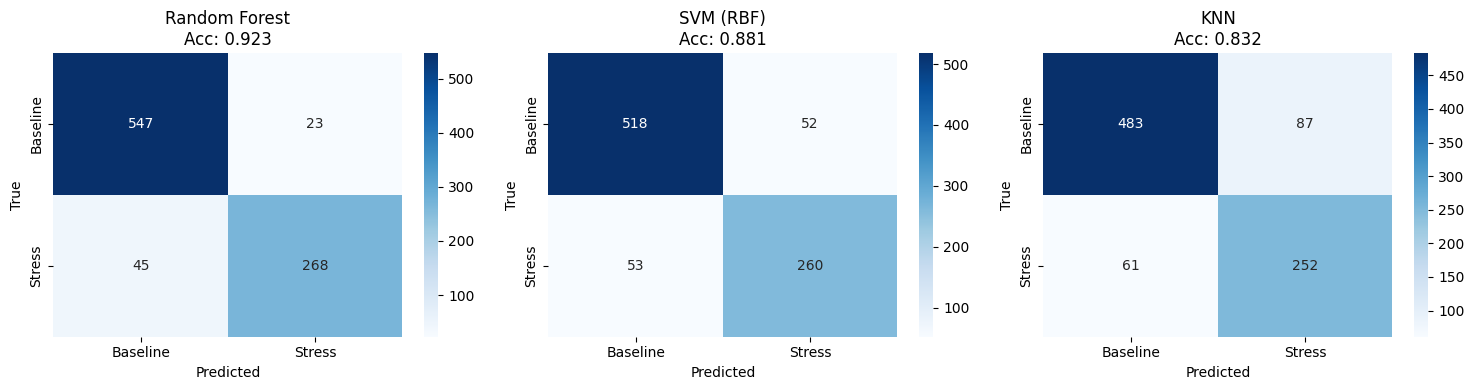

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['truths'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Baseline','Stress'],
                yticklabels=['Baseline','Stress'])
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}")
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

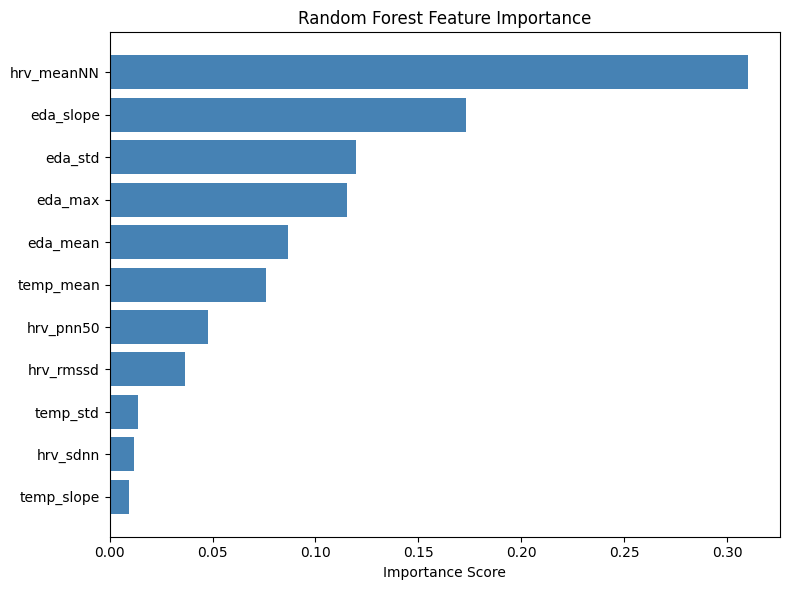

In [ ]:
# Retrain RF on full data for importance plot
X_scaled = StandardScaler().fit_transform(X)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

imp_df = pd.DataFrame({'feature': feat_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

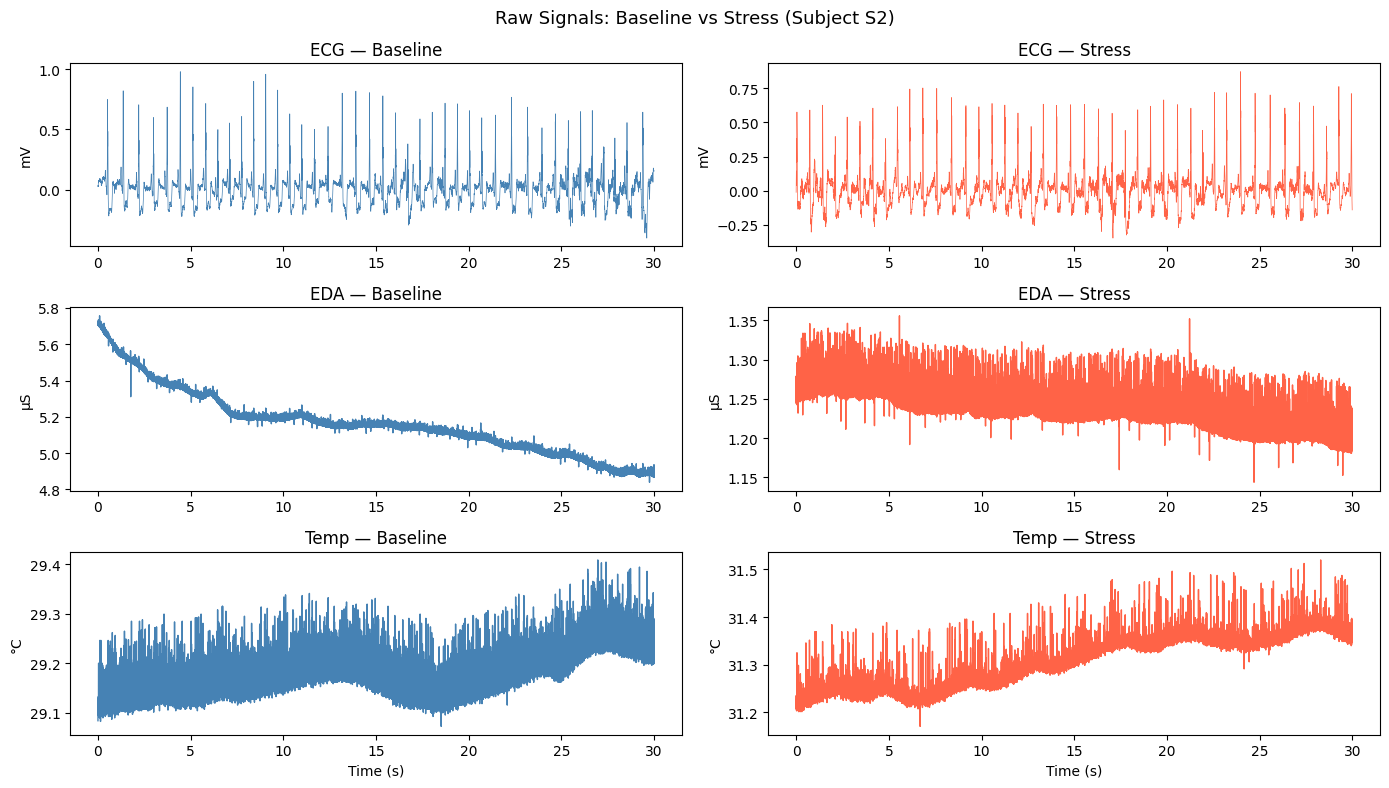

In [ ]:
# Cell: Plot raw signals for one subject
data = load_subject('S2')
signals, labels = extract_signals(data, 'chest')

ecg  = signals['ECG'].flatten()
eda  = signals['EDA'].flatten()
temp = signals['Temp'].flatten()
fs   = 700

# Find baseline and stress segments
baseline_start = np.where(labels == 1)[0][0]
stress_start   = np.where(labels == 2)[0][0]
duration       = fs * 30  # 30 seconds

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle('Raw Signals: Baseline vs Stress (Subject S2)', fontsize=13)

segments = [
    (baseline_start, 'Baseline', 'steelblue'),
    (stress_start,   'Stress',   'tomato')
]

for col, (start, title, color) in enumerate(segments):
    t = np.arange(duration) / fs
    axes[0][col].plot(t, ecg[start:start+duration],  color=color, linewidth=0.5)
    axes[0][col].set_title(f'ECG — {title}'); axes[0][col].set_ylabel('mV')

    axes[1][col].plot(t, eda[start:start+duration],  color=color, linewidth=1)
    axes[1][col].set_title(f'EDA — {title}'); axes[1][col].set_ylabel('µS')

    axes[2][col].plot(t, temp[start:start+duration], color=color, linewidth=1)
    axes[2][col].set_title(f'Temp — {title}'); axes[2][col].set_ylabel('°C')
    axes[2][col].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150)
plt.show()

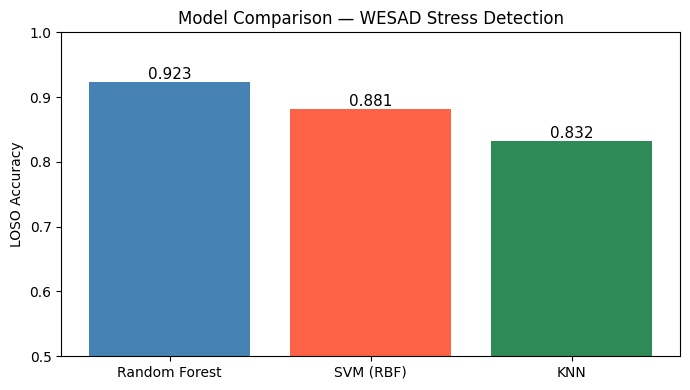

In [ ]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, accuracies, color=['steelblue', 'tomato', 'seagreen'])
plt.ylim(0.5, 1.0)
plt.ylabel('LOSO Accuracy')
plt.title('Model Comparison — WESAD Stress Detection')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
per_subject = []

for train_idx, test_idx in logo.split(X, y, groups):
    test_subject = groups[test_idx][0]
    X_tr, X_te = scaler.fit_transform(X[train_idx]), scaler.transform(X[test_idx])
    rf_model.fit(X_tr, y[train_idx])
    acc = accuracy_score(y[test_idx], rf_model.predict(X_te))
    per_subject.append({'Subject': test_subject, 'Accuracy': round(acc, 3)})

per_subj_df = pd.DataFrame(per_subject).sort_values('Subject')
print(per_subj_df.to_string(index=False))
print(f"\nMean: {per_subj_df['Accuracy'].mean():.3f}  |  Std: {per_subj_df['Accuracy'].std():.3f}")

Subject  Accuracy
    S10     0.700
    S11     0.966
    S13     1.000
    S14     1.000
    S15     0.817
    S16     1.000
    S17     0.967
     S2     0.768
     S3     0.877
     S4     1.000
     S5     1.000
     S6     1.000
     S7     0.814
     S8     1.000
     S9     0.931

Mean: 0.923  |  Std: 0.102
